# Plotting

Currently, NeuRosetta offers two options to plot in 2-dimensions, a more extensive suite for 3-dimensional plotting using [vedo](https://vedo.embl.es/).


In [1]:
import matplotlib.pyplot as plt
import neurosetta as nr

%matplotlib inline

tree = nr.load_example_data(nr.example_ids[0])
tree.summary()


ID,nodes,branches,leaves,cable,units,isReduced,Flag
720575940596125868,2010,99,111,404.2,micron,False,False


## 2D Plots

You have two options here, a 2-dimensional projection, or a dendrogram.

### 2-D plots

Using matplotlib, you can plot neurons in 2D using either `Tree.show_2d()` or `nr.plot_2d(tree)`. Both options do the same thing and have the same arguments. You can use it without having matplotlib directly imported:

<Axes: >

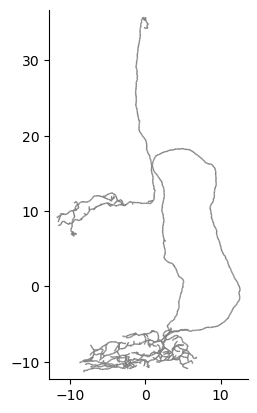

In [2]:
tree.show_2d()

However, as a `matplotlib.pyplot.Axes` object is returned, you can get additional flexibility from matplotlib. You don't technically have to, but you can use the `axes` argument to pass the plot to a created axes object: 

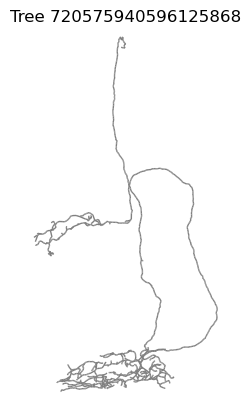

In [3]:
fig, ax = plt.subplots()
tree.show_2d(axes = ax)
ax.set_title(f"Tree {tree.ID}")
ax.set_axis_off()
plt.show()


An important argument to be aware of here is `force_perspective` which is `True` by default. This argument when `True` will rotate the neuron in a way to maximise the viewing field and align it with the global `[x,y]` axis. If False, the native coordinates are used and projected onto whatever the z-axis is:

<Axes: >

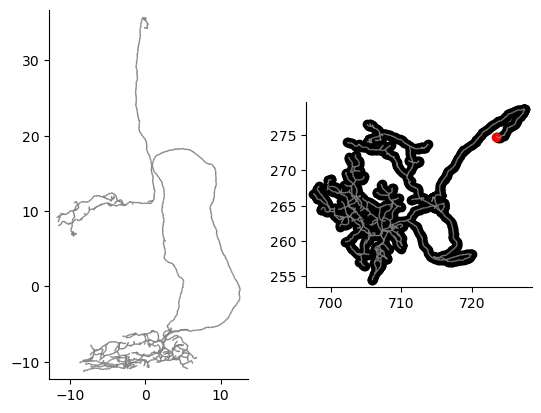

In [4]:
fig, axes = plt.subplots(1,2)

tree.show_2d(force_perspective=True, axes = axes[0])
tree.show_2d(force_perspective=False, axes = axes[1])

### Dendrograms

As above, you have both `tree.show_dendrogram()` and `nr.plot_dendrogram(tree)`.


Text(0.5, 1.0, 'Radial Layout')

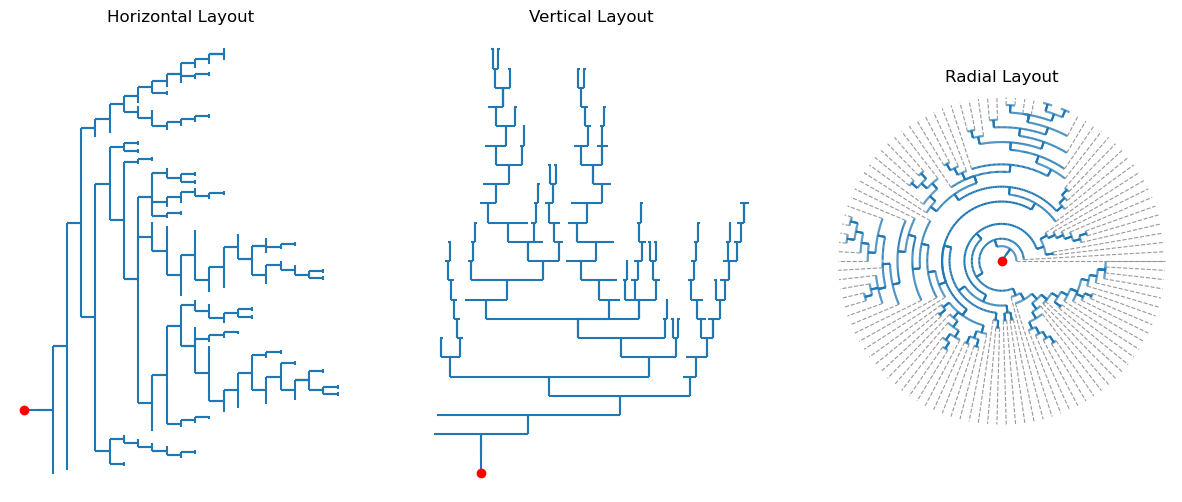

In [5]:
fig, axes = plt.subplots(1,3, figsize = (15,6))

tree.show_dendrogram(orientation = 'horizontal', axes = axes[0])
tree.show_dendrogram(orientation = 'vertical', axes = axes[1])
tree.show_dendrogram(orientation = 'radial', axes = axes[2], align_leaves = True)

axes[0].set_title('Horizontal Layout')
axes[1].set_title('Vertical Layout')
axes[2].set_title('Radial Layout')


I quite enjoy playing with layout algorithms, so I may add more in the future.

## 3-Dimensional Plotting

NeuRosetta uses [vedo](https://vedo.embl.es/site/index.html) to generate interactive 3D plots. By default, this uses `vtk` and opens an external viewing window. Optionally, you can change the backend vedo uses for inline plotting in a notebook. I've had the most luck using `k3d` which is an additional (entierly optional) dependency in the environment, and can be installed with:

```bash
mamba install k3d
```
or
```bash
pip install k3d
```
In your active NeuRosetta environment. For the following examples I am using `k3d`. You can change the default NeuRosetta vedo backend using:

For static documentation builds (`make html`), live Jupyter widgets are not embedded reliably. The example below exports a self-contained k3d HTML snapshot that still renders interactively in the built docs.

In [6]:
nr.config.configure(vedo_backend='k3d');

Read more about the gobal configuration setting for NeuRosetta in {doc}`../reference/configuration`

In [8]:
from neurosetta.testing import make_synthetic_forest, make_synthetic_tree

In [13]:
from IPython.display import HTML

v = nr.Viewer()
v.add_neuron(make_synthetic_tree(), show_root=False)
plot = v.show()

# this is so the plot renders properly in the docs, so ignore it
plot.snapshot_type = "inline"
HTML(plot.get_snapshot())

## Custom Viewer (headless screenshot)


In [ ]:
# from neurosetta import Viewer

# tree_a = nr.load_example_data(forest.ids()[0])
# tree_b = nr.load_example_data(forest.ids()[1])

# with Viewer(interactive=False) as viewer:
#     viewer.add_neuron(tree_a)
#     viewer.add_neuron(tree_b)
#     out = Path(tempfile.mkdtemp()) / "two_neurons.png"
#     viewer.screenshot(str(out))
#     print("wrote", out)


Next: {doc}`tree_surgery`.
